In [9]:
import src.opt as opt
import os
import numpy as np
from sklearn.cluster import SpectralClustering
import cvxpy as cp
import mosek

import src.utils as utils

SAVE = False
PREFIX = './results/sem_neg_araus'

# Check restuls dir exists and create
if not os.path.exists(PREFIX):
    os.makedirs(PREFIX)

## Load and plot data

Original Y shape: (9, 20022). Keeping only the first 2 rows.
Shape of: X: (143, 20022)  -  Y: (2, 20022)  -  data: (145, 20022)
(Min, Max) values of: X: (-9.194, 24.975)  - Y: (1.000, 5.000)  -  data: (-9.194, 24.975)
Mean value of: X: -0.000  -  Y: 2.924  -  data: 0.040
Std value of: X: 1.000  -  Y: 1.137  -  data: 1.058
lamb0: 0.01576588936681814


<Figure size 900x600 with 0 Axes>

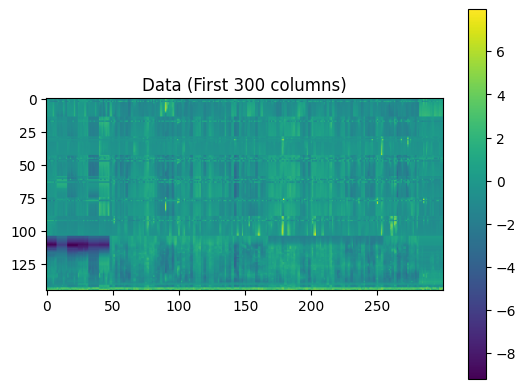

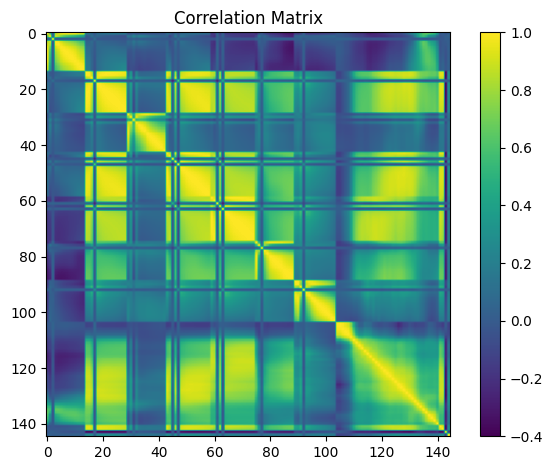

In [ ]:
Data = utils.load_accoustic_data(path_data='data/ARAUS/', y_filename='Y_mean.mat', x_key='X', y_key='Y', sta)
N, M = Data.shape

lamb0 = np.sqrt(np.log(N)/M)
print('lamb0:', lamb0)

## Undirected SEM

In [11]:
# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

# Valence --> pleasantness  [primera]
# Arousal --> eventfulness  [segunda]
# Fijar estas dos salidas, ignorar el resto


# Mults = np.array( [0, 50, 100, 159.78] ) / lamb0
Mults = np.array( [0, 159.78, 472.59] ) / lamb0 / M

# Working with the squared covariance to speed it up
S = Data @ Data.T
w, v = np.linalg.eigh(S)
B = v @ np.diag(np.sqrt(np.maximum(w, 0)))

A_undir_sem = []
for mult in Mults:
    lamb = mult*lamb0

    A_est = opt.sparse_id(B, lamb, symmetric=True, use_cov=True, verbose=False)

    A_undir_sem.append(A_est)
    


In [12]:
# # LOAD DATA
# lamb0s = [159.78]
# A_undir_sem = []
# Mults = [1]*len(lamb0s)
# for lamb0 in lamb0s:
#     file_name = PREFIX + f'/sem_und_{lamb0}.npy'
#     A_undir_sem.append(np.load(file_name, allow_pickle=True))
# A_undir_sem = [np.load(file_name, allow_pickle=True)]


### Plot graph and adjacency

- Lambda: 0.0000  -  Edge density above threshold: 0.220  -  Output edges: 20
- Lambda: 0.0080  -  Edge density above threshold: 0.174  -  Output edges: 20
- Lambda: 0.0236  -  Edge density above threshold: 0.148  -  Output edges: 20


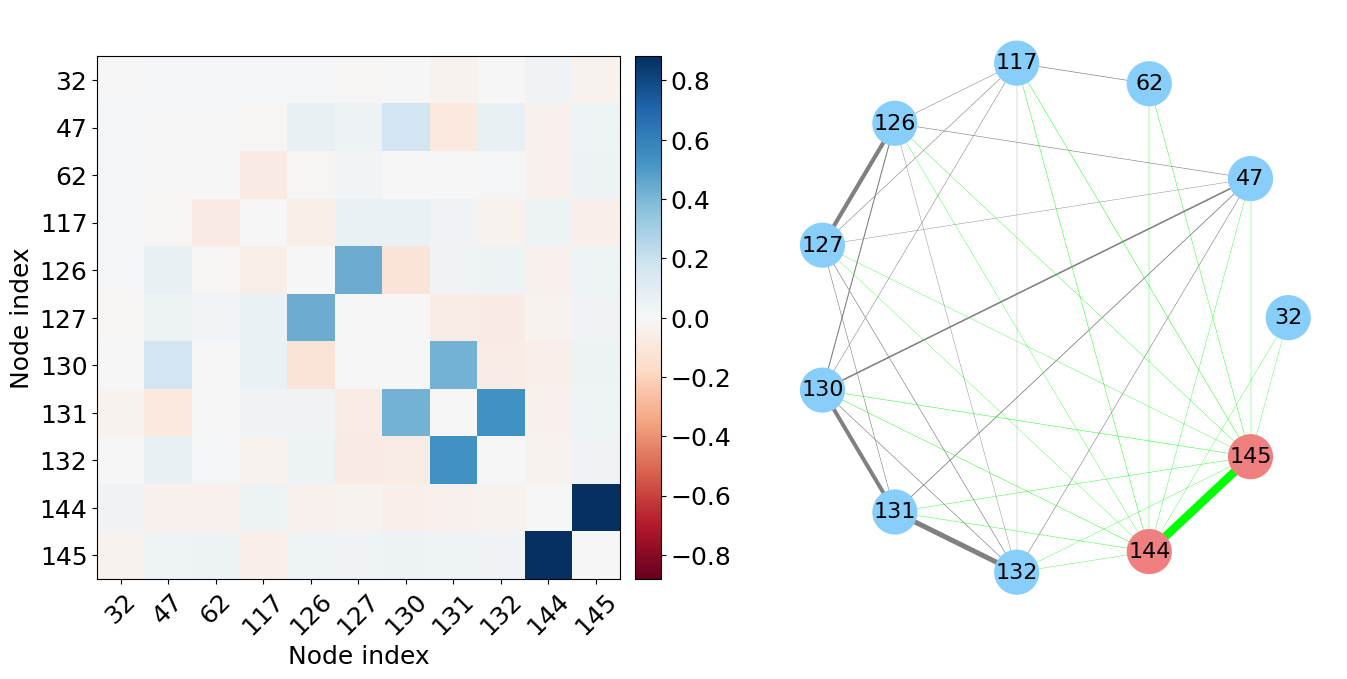

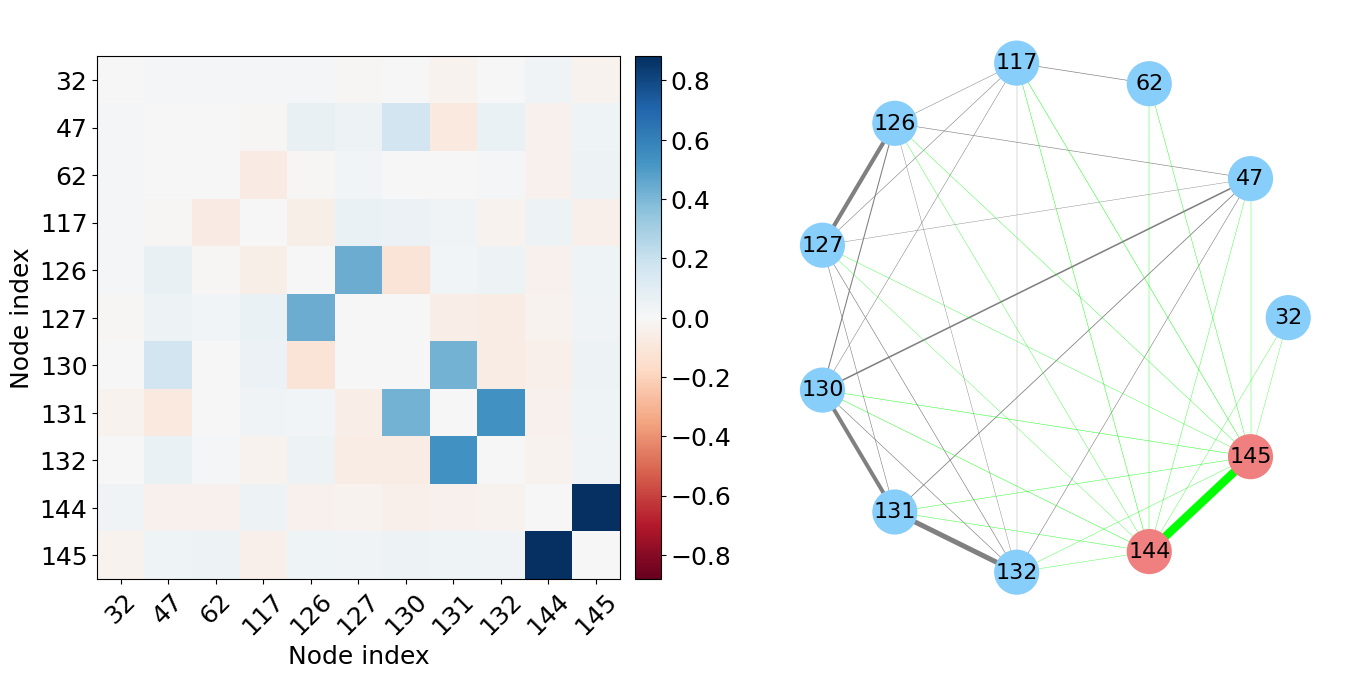

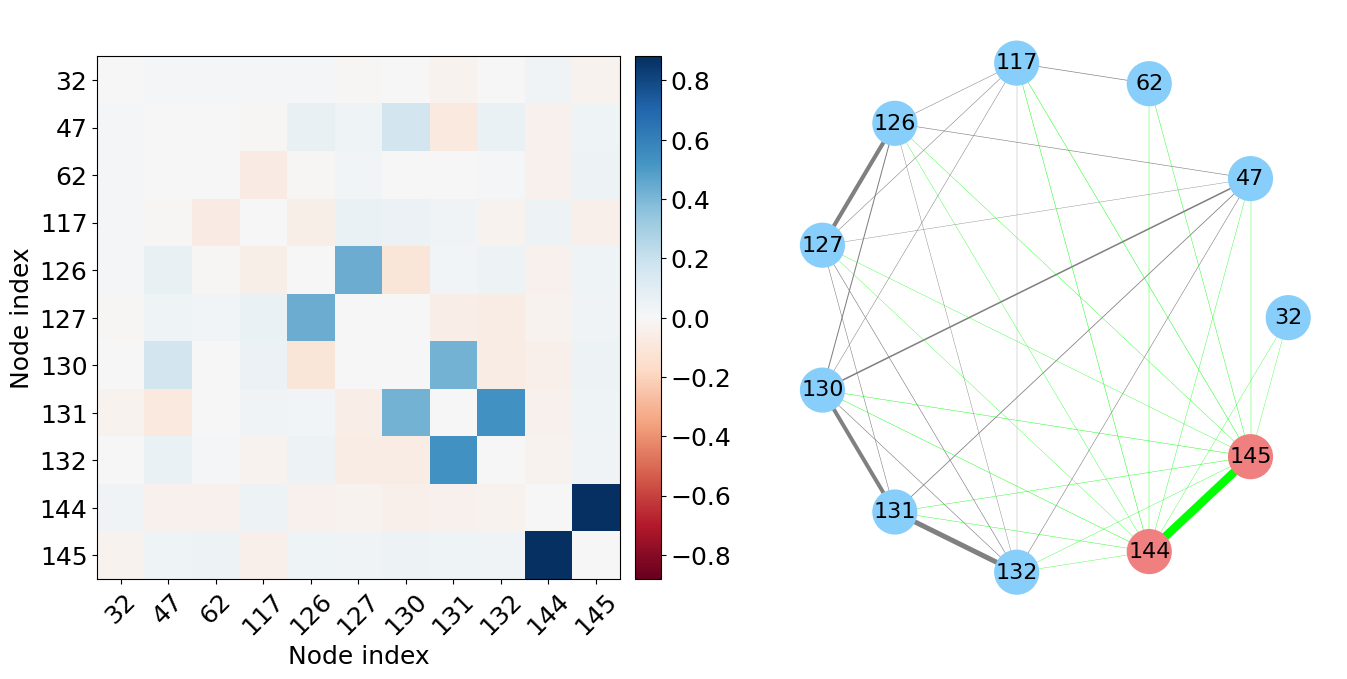

In [19]:
# Plot A
th = 0.03
for i, A_est in enumerate(A_undir_sem):
    mult = Mults[i] * lamb0
    file_name = f'{PREFIX}/sem_und_{mult}'
    # utils.save_plot_graph(A_est, th, mult, max_width=4, file_name=file_name, save=SAVE)
    # save_plot_graph(A_est, th, lamb)
    utils.save_plot_subgraph(A_est, th, mult, save=SAVE, max_width=6, file_name=file_name)
    utils.sort_edges_by_weight(A_est, th, output_file=file_name, abs_val=True, save=SAVE)

## Without connection of outputs variables

In [6]:
PREFIX = './results/sem_neg_unc_arous'

In [20]:

# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

# Mults = np.array( [159.78, 280, 300, 320, 360, 472.59] ) / lamb0
Mults = np.array( [0, 159.78, 472.59] ) / lamb0 / M
S = Data @ Data.T
w, v = np.linalg.eigh(S)
B = v @ np.diag(np.sqrt(np.maximum(w, 0)))


A_undir_sem = []
for mult in Mults:
    lamb = mult*lamb0

    A_est = opt.sparse_id(B, lamb, symmetric=True, zero_indices=[[-1,-2]], use_cov=True, verbose=False)

    A_undir_sem.append(A_est)
    


In [21]:
# # LOAD DATA
# lamb0s = [159.78]
# A_undir_sem = []
# Mults = [1]*len(lamb0s)
# for lamb0 in lamb0s:
#     file_name = PREFIX + f'/sem_und_unc_{lamb0}.npy'
#     A_undir_sem.append(np.load(file_name, allow_pickle=True))
# A_undir_sem = [np.load(file_name, allow_pickle=True)]

### Plot graph and adjacency

- Lambda: 0.0000  -  Edge density above threshold: 0.335  -  Output edges: 11
- Lambda: 0.0080  -  Edge density above threshold: 0.259  -  Output edges: 12
- Lambda: 0.0236  -  Edge density above threshold: 0.216  -  Output edges: 12


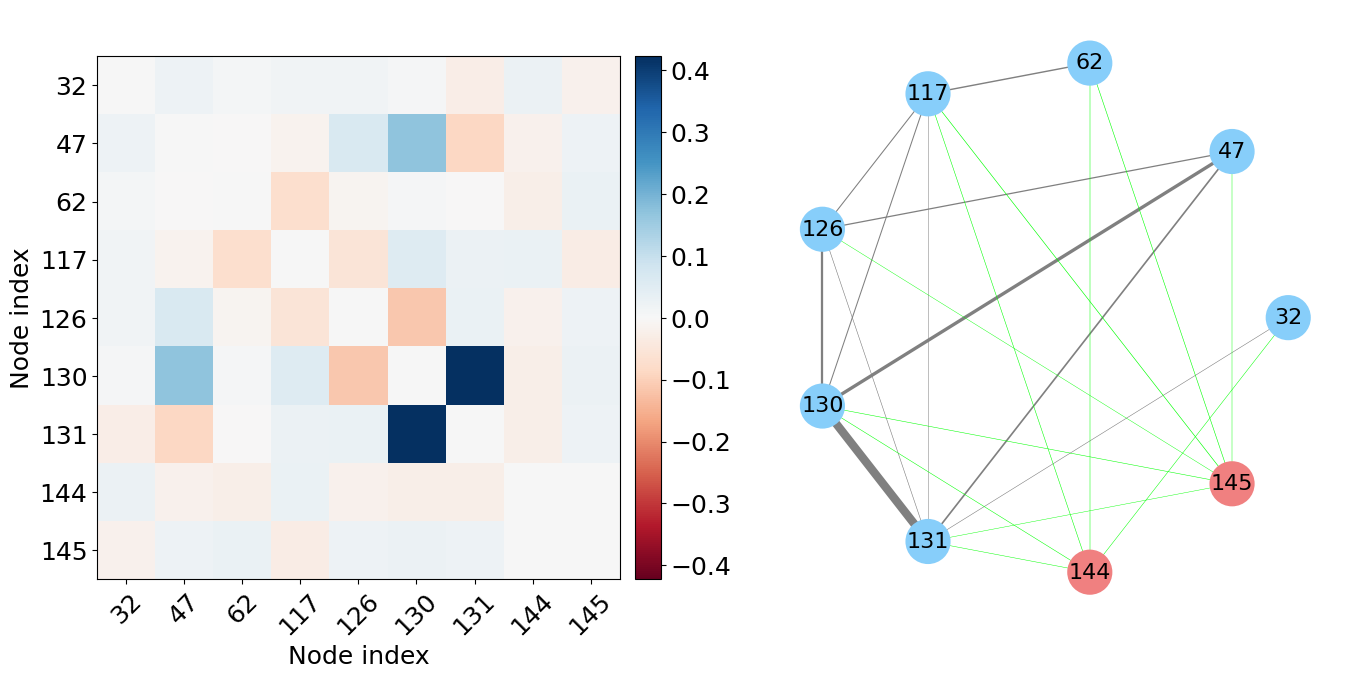

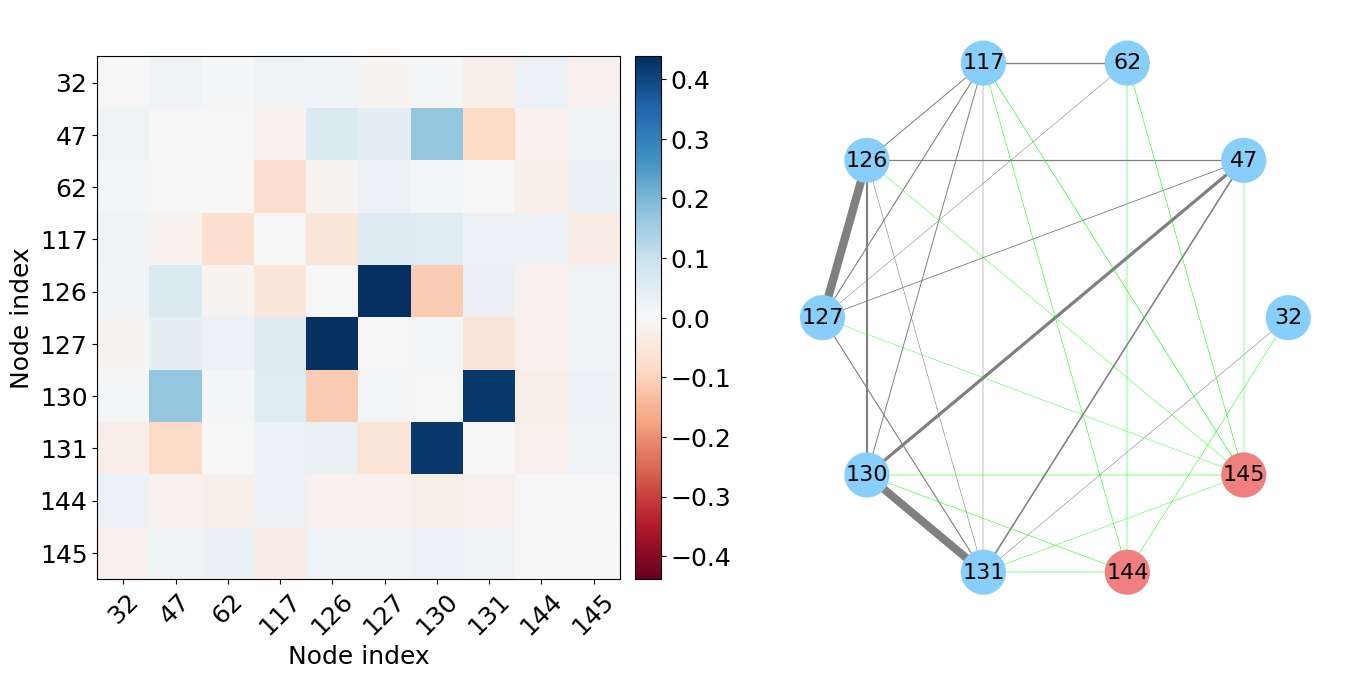

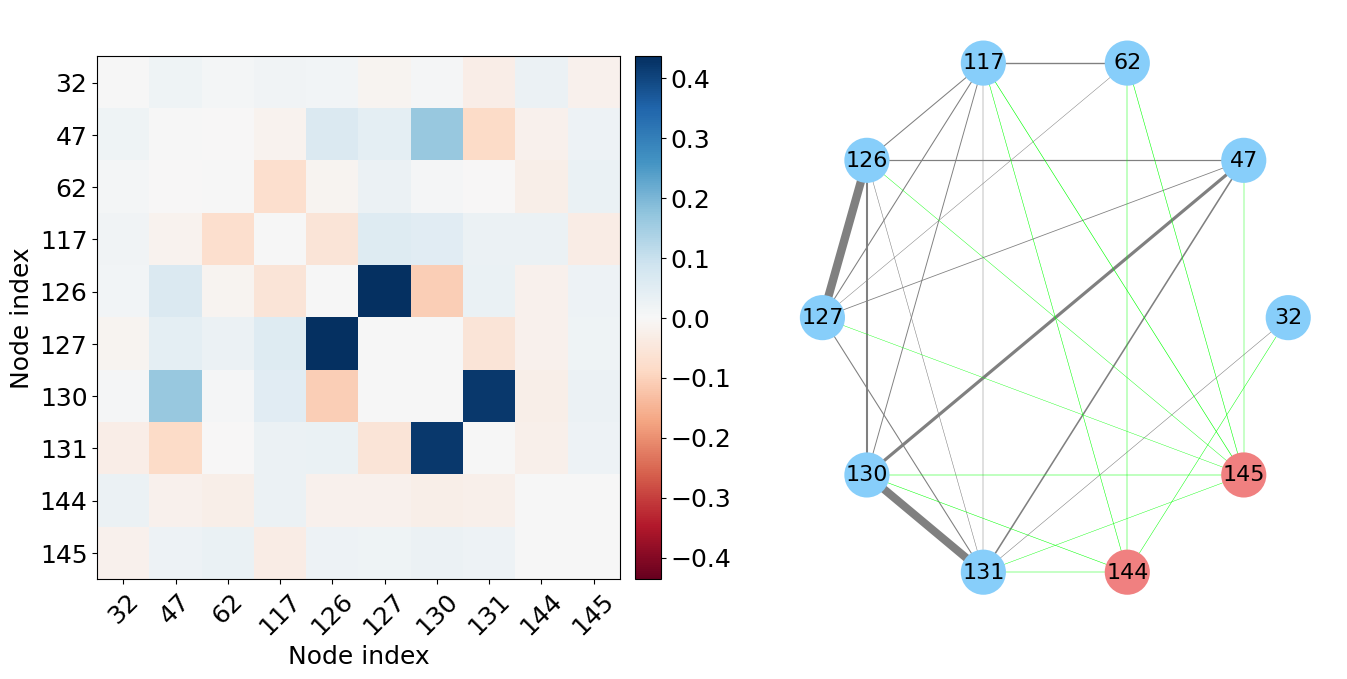

In [25]:
# Plot A
th = 0.02
for i, A_est in enumerate(A_undir_sem):
    mult = Mults[i] * lamb0
    file_name = f'{PREFIX}/sem_und_unc_{mult}'
    # utils.save_plot_graph(A_est, th, mult, max_width=4, file_name=file_name, save=SAVE)
    utils.save_plot_subgraph(A_est, th, mult, save=SAVE, max_width=6, file_name=file_name)
    utils.sort_edges_by_weight(A_est, th, output_file=file_name, abs_val=True, save=SAVE)